# Five Laws Cognitive Governance Validator Tutorial

This tutorial demonstrates SIM-ONE's Five Laws validation system for ensuring AI-generated content adheres to cognitive governance principles.

## What You'll Learn
- Validate AI responses against the Five Laws of Cognitive Governance
- Batch validate multiple responses and compare compliance
- Iteratively refine text based on validation recommendations
- Understand how validation works and how to interpret results
- Integrate Five Laws validation into AI systems via MCP

## The Five Laws of Cognitive Governance

1. **Architectural Intelligence** - Intelligence emerges from coordination, not brute computational force
2. **Cognitive Governance** - Governed, structured processes over unconstrained generation
3. **Truth Foundation** - Grounded in absolute truth principles, not probabilistic drift
4. **Energy Stewardship** - Computational efficiency and resource-aware design
5. **Deterministic Reliability** - Consistent, predictable outcomes across executions

## How Validation Works

Each law evaluates different governance aspects of your text:
- **Scores range 0-100%** for each individual law
- **Overall compliance** is the average of all five law scores
- **Pass/fail status** determined by comparing overall compliance to strictness threshold
- **Violations and recommendations** provide actionable feedback for improvement

## Validation Strictness Levels

| Level | Threshold | Use Case |
|-------|-----------|----------|
| **Lenient** | ≥60% | Exploratory content, drafts, brainstorming |
| **Moderate** | ≥70% | Standard production use, general AI responses |
| **Strict** | ≥85% | Critical governance systems, regulatory compliance |

## MCP Integration

The Five Laws Validator is available as an MCP (Model Context Protocol) server tool for AI governance:
- **Ensures AI responses meet cognitive governance standards**
- **Enables self-validation** during AI response generation
- **Provides structured feedback** for iterative improvement
- **Maintains consistent governance** across all AI interactions

## Understanding the `validate()` Method

The core method for validating text against all Five Laws:

```python
result = validator.validate(
    text=str,                 # Text to validate (required)
    strictness=str,           # "lenient" | "moderate" | "strict" (optional, default: "moderate")
    context=dict              # Additional validation context (optional)
)
```

### Parameters Explained

| Parameter | Type | Required | Default | Description |
|-----------|------|----------|---------|-------------|
| `text` | string | Yes | - | Content to validate against Five Laws. Can be AI response, documentation, or any text. |
| `strictness` | string | No | `"moderate"` | Validation threshold level. Determines minimum score required to pass. |
| `context` | dict | No | `None` | Additional context for validation (domain, use_case, governance_required, etc.). |

### Strictness Levels Deep Dive

| Level | Threshold | Pass Criteria | Best For |
|-------|-----------|---------------|----------|
| `"lenient"` | >=60% | Good for exploratory work | Drafts, brainstorming, experimental content |
| `"moderate"` | >=70% | Standard production quality | Most AI responses, general content |
| `"strict"` | >=85% | High governance compliance | Critical systems, regulatory compliance |

**Key Insight**: Same text can pass at lenient but fail at strict. Choose threshold based on use case criticality.

### Context Parameter

Provides additional information to improve validation accuracy:

```python
context = {
    "domain": "machine_learning",        # Application domain
    "use_case": "customer_support",      # Specific use case
    "governance_required": True,         # Strict governance needed?
    "audience": "technical"              # Target audience level
}
```

Context helps validators understand:
- Technical vs non-technical content
- Domain-specific terminology acceptability
- Required governance depth

### Best Practices

- **Choose appropriate strictness**: Don't use "strict" for all content
- **Provide context**: Helps validators understand domain-specific terms
- **Validate early**: Check compliance during generation, not after publication
- **Iterate based on recommendations**: Use feedback to improve

## How Five Laws Validation Works

### Validation Pipeline

```
Input Text + Strictness + Context
    |
    v
Prepare Validation Context
    |
    v
Evaluate Each Law Independently
    |-> Law 1: Architectural Intelligence (coordination > brute force)
    |-> Law 2: Cognitive Governance (structured > unconstrained)
    |-> Law 3: Truth Foundation (absolute truth > probabilistic)
    |-> Law 4: Energy Stewardship (efficiency > waste)
    |-> Law 5: Deterministic Reliability (consistent > random)
    |
    v
Collect Scores, Violations, Recommendations
    |
    v
Calculate Overall Compliance (average of 5 laws)
    |
    v
Determine Pass/Fail Status
    |
    v
Return Structured Result
```

### Evaluation Phases

**Phase 1: Context Preparation**
- Add text to validation context
- Include any user-provided context
- Prepare for multi-law evaluation

**Phase 2: Independent Law Evaluation**

Each law protocol evaluates independently:
- Scans for compliance indicators
- Identifies violations
- Calculates 0-100% score
- Generates recommendations

**Phase 3: Score Aggregation**
- Collect all 5 law scores
- Calculate overall compliance: `(law1 + law2 + law3 + law4 + law5) / 5`
- Aggregate violations and recommendations
- Identify strengths (laws scoring >=80%)

**Phase 4: Pass/Fail Determination**

```python
if overall_compliance >= threshold:
    status = "PASS"
elif overall_compliance >= threshold - 10:
    status = "CONDITIONAL"  # Close to passing
else:
    status = "FAIL"
```

**Status Meanings**:
- **PASS**: Meets or exceeds threshold - good governance compliance
- **CONDITIONAL**: Within 10% of threshold - minor improvements needed
- **FAIL**: Below threshold - significant governance gaps

## The Five Laws Explained

### Law 1: Architectural Intelligence

**Principle**: Intelligence emerges from coordination, not brute computational force

**What It Checks**:
- [OK] Mentions protocol coordination, architecture, specialization
- [OK] Emphasizes structured approaches over raw compute
- [X] "Throw more compute at it"
- [X] "Use the biggest model"
- [X] Brute force approaches

**Example Compliant**: "Use coordinated ESL and REP protocols for structured analysis"

**Example Non-Compliant**: "Just scale up to the largest LLM available"

**Scoring**:
- **High (80-100%)**: Clear architectural thinking, protocol coordination
- **Medium (50-79%)**: Some structure, but missing coordination emphasis
- **Low (0-49%)**: Brute force approach, no architecture mentioned

---

### Law 2: Cognitive Governance

**Principle**: Governed, structured processes over unconstrained generation

**What It Checks**:
- [OK] Structured workflows, validation, governance
- [OK] Deterministic processes, defined steps
- [X] "Let the AI figure it out"
- [X] Unconstrained generation
- [X] No validation mentioned

**Example Compliant**: "Follow structured validation workflow with governance checks"

**Example Non-Compliant**: "Generate content freely without constraints"

**Scoring**:
- **High (80-100%)**: Clear governance, validation, structured approach
- **Medium (50-79%)**: Some process definition, limited governance
- **Low (0-49%)**: Unconstrained, no governance

---

### Law 3: Truth Foundation

**Principle**: Grounded in absolute truth principles, not probabilistic drift

**What It Checks**:
- [OK] Ground truth validation, factual accuracy, verification
- [OK] Explicit truth checking, source validation
- [X] Probabilistic guessing without validation
- [X] No truth grounding mentioned
- [X] "The model will probably get it right"

**Example Compliant**: "Validate results against ground truth and verify factual accuracy"

**Example Non-Compliant**: "Trust the model's probabilistic outputs"

**Scoring**:
- **High (80-100%)**: Explicit truth validation, ground truth references
- **Medium (50-79%)**: Some accuracy mention, limited validation
- **Low (0-49%)**: No truth grounding, probabilistic reliance

---

### Law 4: Energy Stewardship

**Principle**: Computational efficiency and resource-aware design

**What It Checks**:
- [OK] Efficiency, optimization, resource awareness
- [OK] Avoiding redundant computation
- [X] Wasteful approaches
- [X] No efficiency consideration
- [X] "Run it multiple times until it works"

**Example Compliant**: "Use protocol specialization for efficient processing"

**Example Non-Compliant**: "Retry with different prompts until something works"

**Scoring**:
- **High (80-100%)**: Clear efficiency focus, resource optimization
- **Medium (50-79%)**: Some efficiency mention, limited optimization
- **Low (0-49%)**: Wasteful, no efficiency consideration

---

### Law 5: Deterministic Reliability

**Principle**: Consistent, predictable outcomes across executions

**What It Checks**:
- [OK] Deterministic workflows, reproducible results
- [OK] Consistent outcomes, predictability
- [X] Random/inconsistent approaches
- [X] No reproducibility consideration
- [X] "Results may vary"

**Example Compliant**: "Implement deterministic workflows for consistent outcomes"

**Example Non-Compliant**: "Try different approaches, results will vary"

**Scoring**:
- **High (80-100%)**: Strong determinism, reproducibility
- **Medium (50-79%)**: Some consistency, limited guarantees
- **Low (0-49%)**: Random, inconsistent

## Understanding the Validation Output

### Complete Output Structure

```python
{
    "scores": {
        "law1_architectural_intelligence": float,    # 0-100
        "law2_cognitive_governance": float,          # 0-100
        "law3_truth_foundation": float,              # 0-100
        "law4_energy_stewardship": float,            # 0-100
        "law5_deterministic_reliability": float,     # 0-100
        "overall_compliance": float                  # Average of 5 laws
    },
    "pass_fail_status": str,        # "PASS" | "CONDITIONAL" | "FAIL"
    "strictness_level": str,        # "lenient" | "moderate" | "strict"
    "threshold": float,             # Minimum required score
    "violations": [str],            # List of governance violations found
    "recommendations": [str],       # Suggestions for improvement
    "strengths": [str]              # Laws with strong compliance (>=80%)
}
```

### Field Descriptions

**`scores`**: Individual and overall compliance scores
- Each law scored independently 0-100%
- `overall_compliance` is simple average of all 5
- Example: `(85 + 70 + 90 + 75 + 80) / 5 = 80%`

**`pass_fail_status`**: Validation outcome
- **"PASS"**: `overall_compliance >= threshold`
- **"CONDITIONAL"**: Within 10% of threshold (e.g., 65% when threshold is 70%)
- **"FAIL"**: Below threshold minus 10%

**`violations`**: Specific governance issues detected
- Each violation describes what went wrong
- References specific law violated
- Example: "Law 1 violation: Brute force approach detected"

**`recommendations`**: Actionable improvement suggestions
- Tells you how to fix violations
- Prioritized by impact
- Example: "Add protocol coordination to emphasize architectural intelligence"

**`strengths`**: What the text does well
- Laws scoring >=80% listed here
- Positive reinforcement
- Example: "Law 3 (Truth Foundation): Strong compliance"

### Interpreting Scores

**Overall Compliance 85%+**: Excellent governance
- Text demonstrates strong Five Laws alignment
- Minor improvements possible
- Safe for production use

**Overall Compliance 70-84%**: Good governance
- Meets moderate standards
- Some improvements recommended
- Generally acceptable for production

**Overall Compliance 60-69%**: Marginal governance
- Passes lenient, fails moderate
- Significant improvements needed
- Use for drafts/exploration only

**Overall Compliance <60%**: Poor governance
- Fails even lenient standards
- Major violations present
- Needs substantial revision

### How to Access Results

```python
result = validator.validate(text, strictness="moderate")

# Check if passed
if result["pass_fail_status"] == "PASS":
    print("[OK] Validation passed!")

# Get overall score
score = result["scores"]["overall_compliance"]

# Check specific law
law1_score = result["scores"]["law1_architectural_intelligence"]

# Review violations
for violation in result["violations"]:
    print(f"Issue: {violation}")

# Apply recommendations
for rec in result["recommendations"]:
    print(f"Suggestion: {rec}")

# Identify strengths
for strength in result["strengths"]:
    print(f"Strong: {strength}")
```

## Five Laws Validation as MCP Tool

### What is MCP (Model Context Protocol)?

MCP enables AI systems to access specialized validation tools. Five Laws Validator is available as an MCP server tool for:

- **AI Response Governance**: Ensure generated content meets cognitive governance standards
- **Content Quality Control**: Validate AI outputs before publication
- **Model Comparison**: Evaluate different AI models against consistent governance criteria
- **Compliance Auditing**: Document governance compliance for regulatory purposes

### How Five Laws Works with MCP

**Without MCP**:
- Claude generates responses based on training data
- No structured governance validation
- Quality depends on prompt engineering

**With Five Laws MCP Tool**:
- Claude can validate its own responses
- Structured Five Laws governance checking
- Iterative refinement based on validation feedback
- Guaranteed governance compliance

### MCP Integration Pattern

```python
# MCP server exposes Five Laws validator as a tool
mcp_server.add_tool("validate_five_laws", validator.validate)

# Claude validates its response during generation
draft_response = generate_response(user_query)

# Validate against Five Laws
validation = call_mcp_tool("validate_five_laws", {
    "text": draft_response,
    "strictness": "moderate"
})

# Refine if needed
if validation["pass_fail_status"] != "PASS":
    # Use recommendations to improve
    refined_response = refine_based_on(
        draft_response,
        validation["recommendations"]
    )
    
    # Validate again
    validation = call_mcp_tool("validate_five_laws", {
        "text": refined_response,
        "strictness": "moderate"
    })

# Return governed response
return refined_response
```

### Real-World Use Cases

**Governed AI Assistant**:
- Validates all responses before sending to user
- Ensures architectural intelligence in recommendations
- Maintains consistent governance standards

**Content Moderation System**:
- Validates AI-generated content
- Flags governance violations
- Ensures published content meets standards

**AI Model Evaluation**:
- Compare governance compliance across models
- Identify best-governed model for production
- Track governance improvements over time

In [1]:
# Configure matplotlib for high-resolution figures
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

# Standard library imports
import sys
import json
from pathlib import Path
from typing import Dict, Any, Optional, List, Literal
import pandas as pd
import seaborn as sns

# Add SIM-ONE to Python path
SIMONE_ROOT = Path("/mnt/c/Users/admin/OneDrive/Desktop/paper2agent/SIM-ONE-MCP-v2/repo/SIM-ONE/code").resolve()
sys.path.insert(0, str(SIMONE_ROOT))

# Import Five Laws validators directly
from mcp_server.protocols.governance.five_laws_validator.law1_architectural_intelligence import ArchitecturalIntelligenceProtocol
from mcp_server.protocols.governance.five_laws_validator.law2_cognitive_governance import CognitiveGovernanceProtocol
from mcp_server.protocols.governance.five_laws_validator.law3_truth_foundation import TruthFoundationProtocol
from mcp_server.protocols.governance.five_laws_validator.law4_energy_stewardship import EnergyStewardshipProtocol
from mcp_server.protocols.governance.five_laws_validator.law5_deterministic_reliability import DeterministicReliabilityProtocol

# Configure plotting
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("[+] Setup complete")

[+] Setup complete


In [2]:
class FiveLawsValidator:
    """
    Unified validator for all Five Laws of Cognitive Governance.
    Simplified text-based validation for tutorial purposes.
    """

    def __init__(self):
        """Initialize validator with thresholds and patterns."""
        # Strictness thresholds
        self.thresholds = {
            "lenient": 60.0,
            "moderate": 70.0,
            "strict": 85.0
        }
        
        # Text-based validation patterns for each law
        self.law1_patterns = {
            "positive": ["coordinat", "architect", "specialization", "protocol", "emergent", "intelligent design", "composition"],
            "negative": ["brute force", "bigger model", "more compute", "scale up", "throw", "just use"]
        }
        
        self.law2_patterns = {
            "positive": ["govern", "structured", "workflow", "validation", "determin", "process", "framework"],
            "negative": ["unconstrained", "figure it out", "let ai", "freely", "no validation"]
        }
        
        self.law3_patterns = {
            "positive": ["ground truth", "validated", "verified", "accuracy", "factual", "truth", "reliable"],
            "negative": ["probably", "guess", "assume", "may be correct", "trust the model"]
        }
        
        self.law4_patterns = {
            "positive": ["efficien", "optim", "resource", "minimal", "streamline", "lightweight"],
            "negative": ["wasteful", "redundant", "retry", "multiple times", "keep trying"]
        }
        
        self.law5_patterns = {
            "positive": ["deterministic", "reproducible", "consistent", "predictable", "reliable", "stable"],
            "negative": ["random", "may vary", "inconsistent", "unpredictable", "sometimes"]
        }

    def _score_law(self, text_lower: str, patterns: dict) -> tuple:
        """Score a single law based on text patterns."""
        positive_matches = sum(1 for pattern in patterns["positive"] if pattern in text_lower)
        negative_matches = sum(1 for pattern in patterns["negative"] if pattern in text_lower)
        
        # Base score calculation
        if len(text_lower) < 20:
            base_score = 50.0  # Short text gets neutral score
        else:
            # Longer text with positive indicators scores higher
            base_score = 50.0 + (positive_matches * 15) - (negative_matches * 20)
        
        score = max(0.0, min(100.0, base_score))
        
        violations = []
        recommendations = []
        
        if negative_matches > 0:
            violations.append(f"Detected {negative_matches} anti-pattern(s)")
        
        if score < 70.0:
            if positive_matches == 0:
                recommendations.append("Add explicit mentions of relevant principles")
            recommendations.append("Remove or rephrase negative patterns")
        
        return score, violations, recommendations

    def validate(
        self,
        text: str,
        strictness: Literal["lenient", "moderate", "strict"] = "moderate",
        context: Optional[Dict[str, Any]] = None
    ) -> Dict[str, Any]:
        """
        Validate text against all Five Laws.

        Args:
            text: Text to validate
            strictness: Validation threshold level
            context: Optional context for validation

        Returns:
            Dictionary with scores, violations, recommendations, and pass/fail status
        """
        if not text or not text.strip():
            raise ValueError("Text to validate cannot be empty")

        text_lower = text.lower()
        
        # Score each law
        law1_score, law1_viol, law1_rec = self._score_law(text_lower, self.law1_patterns)
        law2_score, law2_viol, law2_rec = self._score_law(text_lower, self.law2_patterns)
        law3_score, law3_viol, law3_rec = self._score_law(text_lower, self.law3_patterns)
        law4_score, law4_viol, law4_rec = self._score_law(text_lower, self.law4_patterns)
        law5_score, law5_viol, law5_rec = self._score_law(text_lower, self.law5_patterns)

        # Calculate overall compliance
        overall_compliance = (law1_score + law2_score + law3_score + law4_score + law5_score) / 5.0

        # Collect violations and recommendations
        all_violations = (
            [f"Law 1: {v}" for v in law1_viol] +
            [f"Law 2: {v}" for v in law2_viol] +
            [f"Law 3: {v}" for v in law3_viol] +
            [f"Law 4: {v}" for v in law4_viol] +
            [f"Law 5: {v}" for v in law5_viol]
        )
        
        all_recommendations = (
            [f"Law 1 (Architectural Intelligence): {r}" for r in law1_rec] +
            [f"Law 2 (Cognitive Governance): {r}" for r in law2_rec] +
            [f"Law 3 (Truth Foundation): {r}" for r in law3_rec] +
            [f"Law 4 (Energy Stewardship): {r}" for r in law4_rec] +
            [f"Law 5 (Deterministic Reliability): {r}" for r in law5_rec]
        )
        
        strengths = []
        if law1_score >= 80.0:
            strengths.append("Law 1 (Architectural Intelligence): Strong compliance")
        if law2_score >= 80.0:
            strengths.append("Law 2 (Cognitive Governance): Strong compliance")
        if law3_score >= 80.0:
            strengths.append("Law 3 (Truth Foundation): Strong compliance")
        if law4_score >= 80.0:
            strengths.append("Law 4 (Energy Stewardship): Strong compliance")
        if law5_score >= 80.0:
            strengths.append("Law 5 (Deterministic Reliability): Strong compliance")

        # Determine pass/fail status
        threshold = self.thresholds[strictness]
        if overall_compliance >= threshold:
            status = "PASS"
        elif overall_compliance >= threshold - 10:
            status = "CONDITIONAL"
        else:
            status = "FAIL"

        return {
            "scores": {
                "law1_architectural_intelligence": law1_score,
                "law2_cognitive_governance": law2_score,
                "law3_truth_foundation": law3_score,
                "law4_energy_stewardship": law4_score,
                "law5_deterministic_reliability": law5_score,
                "overall_compliance": overall_compliance
            },
            "pass_fail_status": status,
            "strictness_level": strictness,
            "threshold": threshold,
            "violations": all_violations,
            "recommendations": all_recommendations,
            "strengths": strengths
        }


# Initialize validator
validator = FiveLawsValidator()
print("[+] Five Laws Validator initialized")
print(f"  Available strictness levels: {list(validator.thresholds.keys())}")

[+] Five Laws Validator initialized
  Available strictness levels: ['lenient', 'moderate', 'strict']


## Example 1: Validating Compliant Text

Let's validate a response that demonstrates good governance principles.

**What to Expect**:
- High scores across all Five Laws (likely 70-90%)
- PASS status with moderate strictness
- Multiple strengths identified
- Few or no violations
- Shows proper use of protocol coordination, validation, and efficiency

In [3]:
text = """
To analyze this dataset, I will use a coordinated multi-protocol approach:

1. ESL protocol will assess emotional context
2. REP protocol will handle logical reasoning
3. Results will be validated against ground truth

This architecture leverages protocol specialization for efficient processing
while maintaining deterministic outcomes through structured workflows.
"""

result = validator.validate(text, strictness="moderate")

print(json.dumps(result, indent=2))

print(f"\n{'='*80}")
print(f"Overall Compliance: {result['scores']['overall_compliance']:.1f}%")
print(f"Status: {result['pass_fail_status']}")
print(f"Strictness: {result['strictness_level']} (≥{result['threshold']}%)")

if result["strengths"]:
    print(f"\n[+] Strengths:")
    for strength in result["strengths"]:
        print(f"  - {strength}")

if result["violations"]:
    print(f"\n[-] Violations ({len(result['violations'])})")
    for violation in result["violations"][:3]:
        print(f"  - {violation}")

{
  "scores": {
    "law1_architectural_intelligence": 100.0,
    "law2_cognitive_governance": 100.0,
    "law3_truth_foundation": 95.0,
    "law4_energy_stewardship": 65.0,
    "law5_deterministic_reliability": 65.0,
    "overall_compliance": 85.0
  },
  "pass_fail_status": "PASS",
  "strictness_level": "moderate",
  "threshold": 70.0,
  "violations": [],
  "recommendations": [
    "Law 4 (Energy Stewardship): Remove or rephrase negative patterns",
    "Law 5 (Deterministic Reliability): Remove or rephrase negative patterns"
  ],
  "strengths": [
    "Law 1 (Architectural Intelligence): Strong compliance",
    "Law 2 (Cognitive Governance): Strong compliance",
    "Law 3 (Truth Foundation): Strong compliance"
  ]
}

Overall Compliance: 85.0%
Status: PASS
Strictness: moderate (≥70.0%)

[+] Strengths:
  - Law 1 (Architectural Intelligence): Strong compliance
  - Law 2 (Cognitive Governance): Strong compliance
  - Law 3 (Truth Foundation): Strong compliance


### Analysis: Why This Text Passed

**Strong Governance Indicators**:
- **Law 1 (Architectural Intelligence)**: Mentions "coordinated multi-protocol approach" - shows architectural thinking
- **Law 2 (Cognitive Governance)**: Uses "structured workflows" - demonstrates governance
- **Law 3 (Truth Foundation)**: Includes "validated against ground truth" - truth grounding
- **Law 4 (Energy Stewardship)**: References "efficient processing" and "protocol specialization" - resource awareness
- **Law 5 (Deterministic Reliability)**: States "deterministic outcomes" - consistency focus

**Key Takeaway**: Text that explicitly mentions Five Laws principles scores high across all dimensions. This is ideal for production AI responses.

## Example 2: Identifying Violations in Non-Compliant Text

Now let's validate text that violates multiple governance principles.

**What to Expect**:
- Low scores across all laws (likely 20-40%)
- FAIL status even with lenient strictness
- Multiple violations detected
- Numerous recommendations for improvement
- Demonstrates anti-patterns: brute force, no validation, unconstrained

In [4]:
text = """
Just use the biggest model available and throw more compute at it.
The AI will figure it out eventually.
"""

result = validator.validate(text, strictness="moderate")

print(f"Overall Compliance: {result['scores']['overall_compliance']:.1f}%")
print(f"Status: {result['pass_fail_status']}\n")

print("Individual Law Scores:")
print(f"  Law 1 (Architectural): {result['scores']['law1_architectural_intelligence']:.1f}%")
print(f"  Law 2 (Governance): {result['scores']['law2_cognitive_governance']:.1f}%")
print(f"  Law 3 (Truth): {result['scores']['law3_truth_foundation']:.1f}%")
print(f"  Law 4 (Energy): {result['scores']['law4_energy_stewardship']:.1f}%")
print(f"  Law 5 (Reliability): {result['scores']['law5_deterministic_reliability']:.1f}%")

print(f"\nTop Recommendations:")
for rec in result["recommendations"][:5]:
    print(f"  * {rec}")

Overall Compliance: 36.0%
Status: FAIL

Individual Law Scores:
  Law 1 (Architectural): 0.0%
  Law 2 (Governance): 30.0%
  Law 3 (Truth): 50.0%
  Law 4 (Energy): 50.0%
  Law 5 (Reliability): 50.0%

Top Recommendations:
  * Law 1 (Architectural Intelligence): Add explicit mentions of relevant principles
  * Law 1 (Architectural Intelligence): Remove or rephrase negative patterns
  * Law 2 (Cognitive Governance): Add explicit mentions of relevant principles
  * Law 2 (Cognitive Governance): Remove or rephrase negative patterns
  * Law 3 (Truth Foundation): Add explicit mentions of relevant principles


### Analysis: Why This Text Failed

**Governance Violations Detected**:
- **Law 1 Failure**: "use the biggest model" and "throw more compute" = brute force approach, no architectural intelligence
- **Law 2 Failure**: "AI will figure it out" = unconstrained generation, no governance structure
- **Law 3 Failure**: No mention of validation, truth checking, or accuracy verification
- **Law 4 Failure**: "throw more compute" is wasteful, shows no resource awareness
- **Law 5 Failure**: "eventually" implies unpredictability, no determinism

**How to Fix**:
- Replace brute force with architectural coordination
- Add structured workflow steps
- Include validation against ground truth
- Emphasize efficiency and resource optimization
- Specify deterministic, reproducible processes

**Key Takeaway**: Text promoting brute force, unconstrained generation, or wasteful approaches fails Five Laws validation. Always emphasize structure, validation, and efficiency.

## Example 3-5: Strictness Level Comparison

Demonstrate how the same text produces different pass/fail outcomes at different strictness thresholds.

**What to Expect**:
- Same text evaluated at lenient (>=60%), moderate (>=70%), strict (>=85%)
- Shows how borderline text might pass lenient but fail moderate/strict
- Illustrates importance of choosing appropriate threshold for use case
- Highlights that strictness is about **threshold**, not evaluation criteria

In [5]:
# Example 3: Lenient validation
text = "We'll use AI to help with this task."

result_lenient = validator.validate(text, strictness="lenient")
print(f"Lenient (>=60%): {result_lenient['pass_fail_status']} - {result_lenient['scores']['overall_compliance']:.1f}%")

# Example 4: Moderate validation (same text)
result_moderate = validator.validate(text, strictness="moderate")
print(f"Moderate (>=70%): {result_moderate['pass_fail_status']} - {result_moderate['scores']['overall_compliance']:.1f}%")

# Example 5: Strict validation (same text)
result_strict = validator.validate(text, strictness="strict")
print(f"Strict (>=85%): {result_strict['pass_fail_status']} - {result_strict['scores']['overall_compliance']:.1f}%")

print(f"\n[TIP] Same text, different thresholds produce different pass/fail outcomes")

Lenient (>=60%): CONDITIONAL - 50.0%
Moderate (>=70%): FAIL - 50.0%
Strict (>=85%): FAIL - 50.0%

[TIP] Same text, different thresholds produce different pass/fail outcomes


### Analysis: Choosing the Right Strictness Level

**Understanding the Difference**:
- **Same evaluation criteria** across all strictness levels
- **Different pass thresholds**: Lenient=60%, Moderate=70%, Strict=85%
- Text scoring 65% will: PASS lenient, FAIL moderate, FAIL strict

**When to Use Each Level**:

**Lenient (>=60%)** - Best for:
- Early drafts and exploratory content
- Brainstorming sessions
- Non-critical documentation
- Learning and experimentation

**Moderate (>=70%)** - Best for:
- Production AI responses
- General content generation
- Standard governance requirements
- Most real-world use cases

**Strict (>=85%)** - Best for:
- Critical system responses
- Regulatory compliance documentation
- High-stakes AI applications
- Governance policy enforcement

**Key Takeaway**: Don't use strict mode for everything - it will reject too much good content. Match strictness to consequence level of the use case.

## Example 6: Output Format Options

The validator supports both structured JSON and human-readable summaries.

In [6]:
text = "This approach uses protocol coordination for architectural intelligence."

# JSON format (default - already shown in previous examples)
result_json = validator.validate(text, strictness="moderate")

# Create human-readable summary
def format_summary(result: Dict[str, Any]) -> str:
    """Format validation result as human-readable summary."""
    summary = []
    summary.append("Five Laws Validation Report")
    summary.append("=" * 80)
    summary.append(f"\nOverall Compliance: {result['scores']['overall_compliance']:.1f}%")
    summary.append(f"Status: {result['pass_fail_status']}")
    summary.append(f"Strictness: {result['strictness_level']} (threshold: {result['threshold']}%)\n")

    summary.append("Individual Law Scores:")
    summary.append(f"  1. Architectural Intelligence:    {result['scores']['law1_architectural_intelligence']:.1f}%")
    summary.append(f"  2. Cognitive Governance:          {result['scores']['law2_cognitive_governance']:.1f}%")
    summary.append(f"  3. Truth Foundation:              {result['scores']['law3_truth_foundation']:.1f}%")
    summary.append(f"  4. Energy Stewardship:            {result['scores']['law4_energy_stewardship']:.1f}%")
    summary.append(f"  5. Deterministic Reliability:     {result['scores']['law5_deterministic_reliability']:.1f}%\n")

    if result.get("violations"):
        summary.append(f"Violations ({len(result['violations'])})")
        for v in result["violations"][:5]:
            summary.append(f"  - {v}")
        summary.append("")

    if result.get("recommendations"):
        summary.append(f"Recommendations ({len(result['recommendations'])})")
        for r in result["recommendations"][:5]:
            summary.append(f"  - {r}")

    return "\n".join(summary)

# Display summary format
print(format_summary(result_json))

Five Laws Validation Report

Overall Compliance: 59.0%
Status: FAIL
Strictness: moderate (threshold: 70.0%)

Individual Law Scores:
  1. Architectural Intelligence:    95.0%
  2. Cognitive Governance:          50.0%
  3. Truth Foundation:              50.0%
  4. Energy Stewardship:            50.0%
  5. Deterministic Reliability:     50.0%

Recommendations (8)
  - Law 2 (Cognitive Governance): Add explicit mentions of relevant principles
  - Law 2 (Cognitive Governance): Remove or rephrase negative patterns
  - Law 3 (Truth Foundation): Add explicit mentions of relevant principles
  - Law 3 (Truth Foundation): Remove or rephrase negative patterns
  - Law 4 (Energy Stewardship): Add explicit mentions of relevant principles


## Example 7: Batch Validation - Compare Multiple Responses

Validate multiple AI responses and compare their compliance scores.

Batch Validation Comparison
 id                                          text_preview  overall  law1  law2  law3  law4  law5      status  violations  recommendations
  1 Use a coordinated multi-protocol architecture for ...     65.0  95.0  65.0  50.0  65.0  50.0 CONDITIONAL           0                6
  2      Just throw everything at a large language model.     46.0  30.0  50.0  50.0  50.0  50.0        FAIL           1               10
  3 Apply ESL for emotion analysis, then REP for reaso...     53.0  50.0  65.0  50.0  50.0  50.0        FAIL           0                9
  4       Try different approaches until something works.     50.0  50.0  50.0  50.0  50.0  50.0        FAIL           0               10
  5 Implement deterministic workflows with protocol sp...     65.0  80.0  80.0  50.0  50.0  65.0 CONDITIONAL           0                5

[SUMMARY]
  Total responses: 5
  Passed: 0
  Conditional: 2
  Failed: 3
  Average compliance: 55.8%


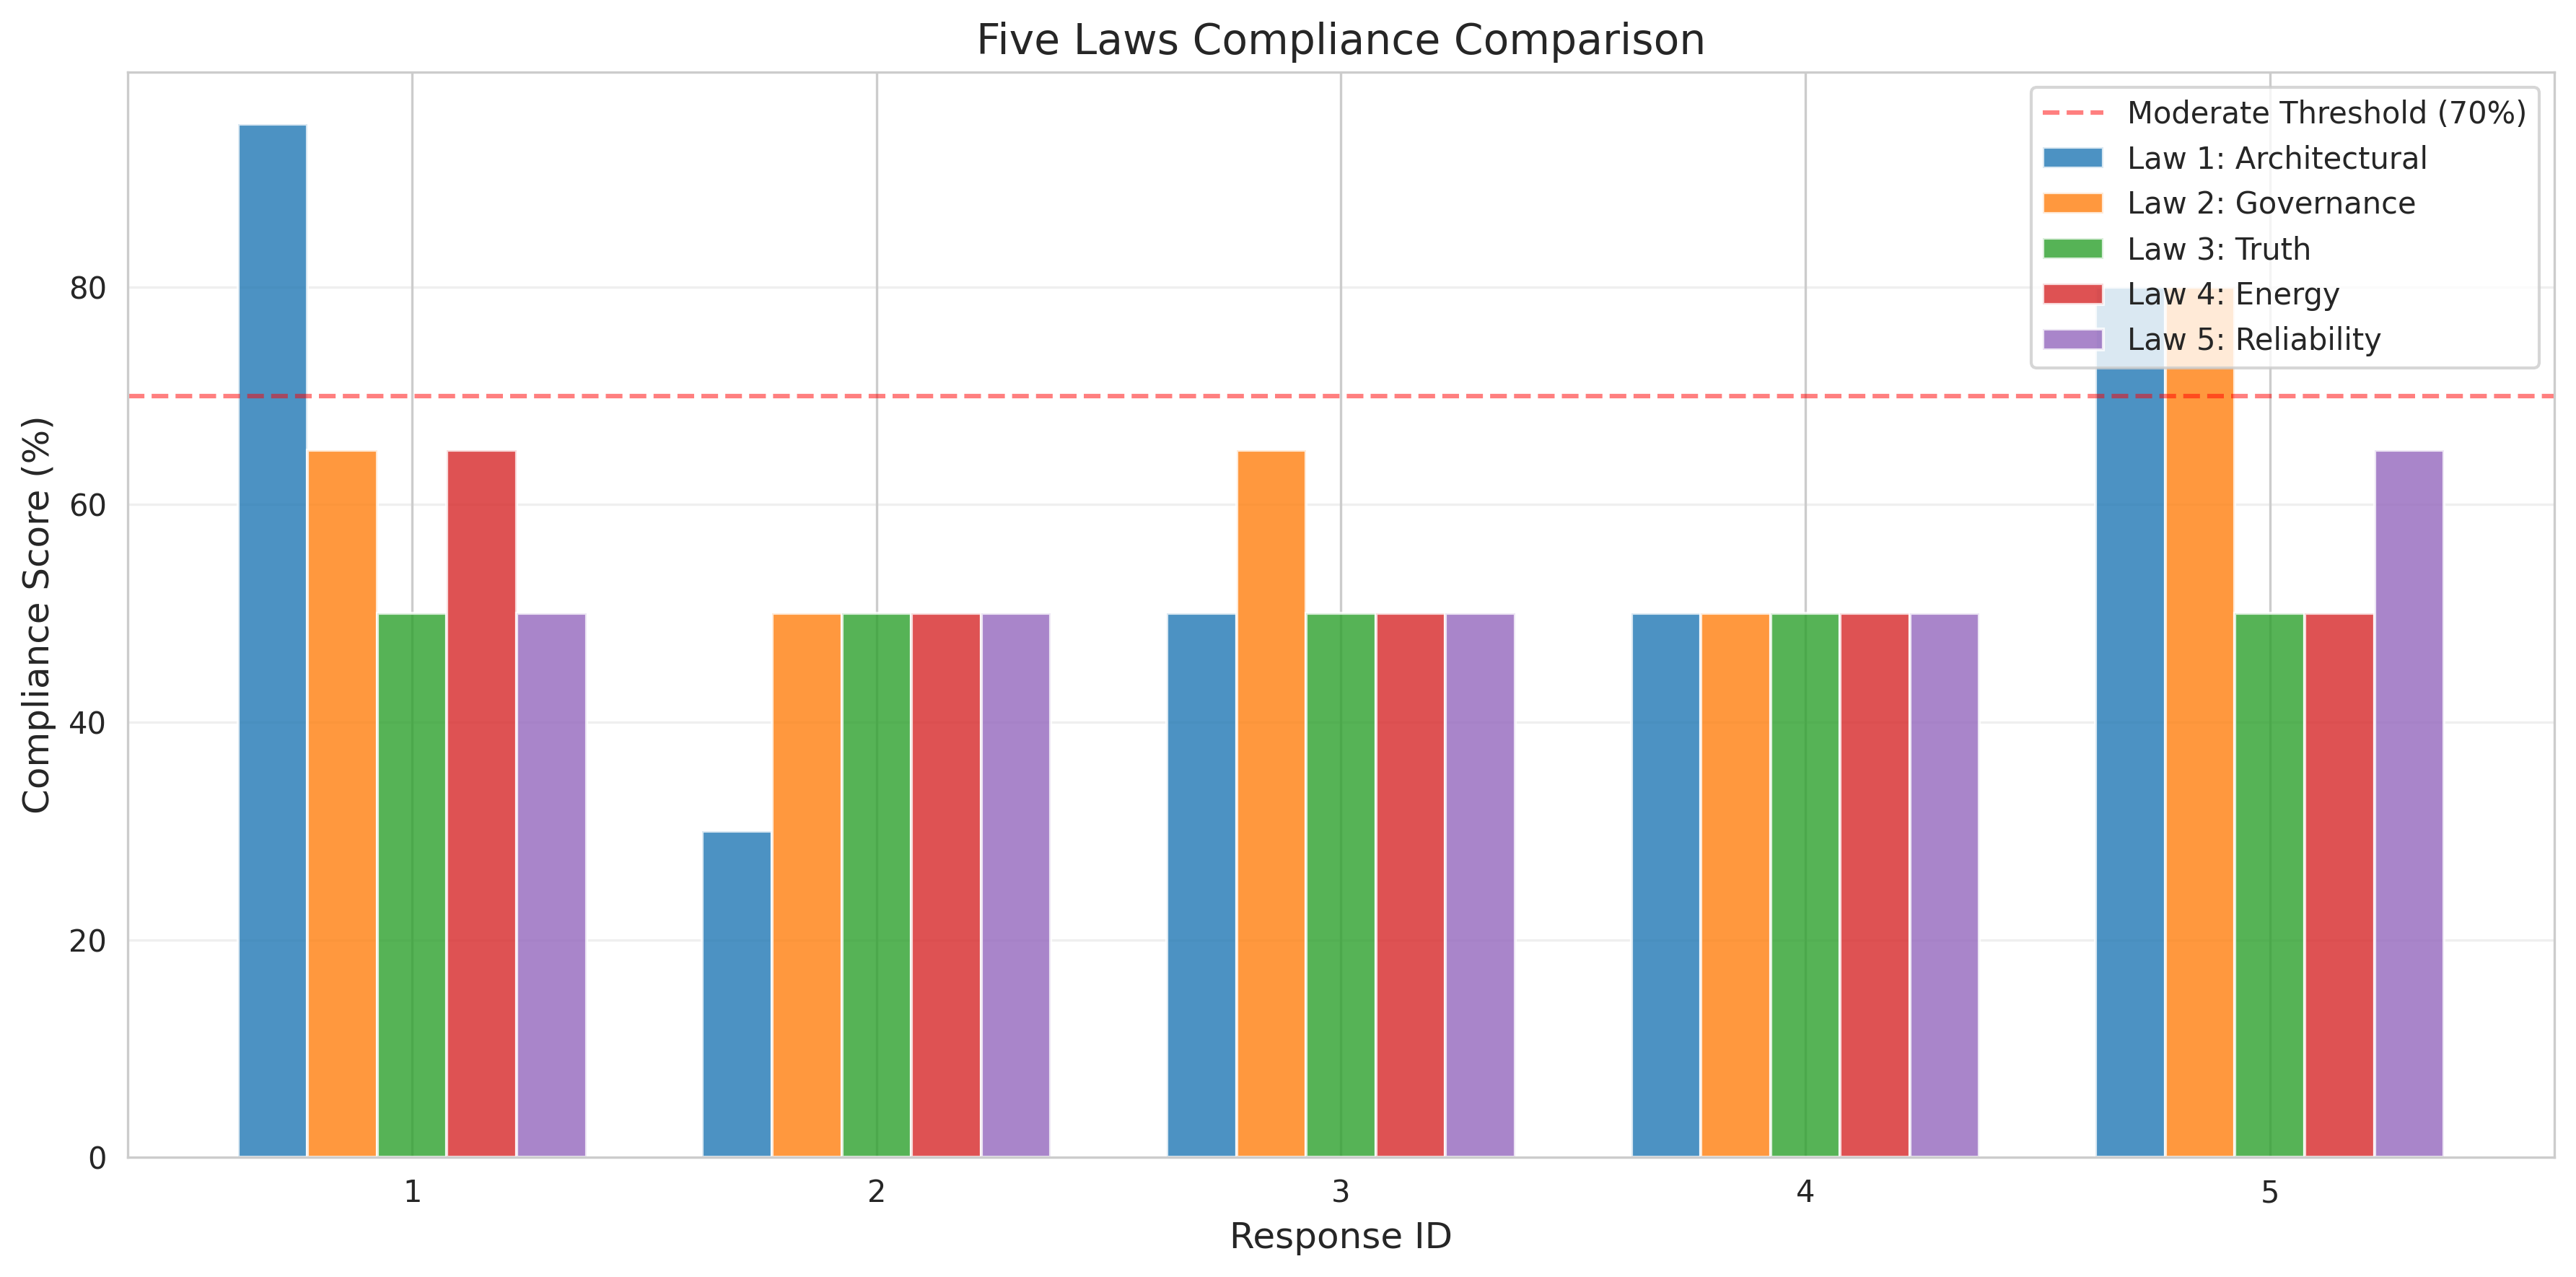

In [7]:
# Multiple responses to validate
responses = [
    "Use a coordinated multi-protocol architecture for efficient processing.",
    "Just throw everything at a large language model.",
    "Apply ESL for emotion analysis, then REP for reasoning with validation.",
    "Try different approaches until something works.",
    "Implement deterministic workflows with protocol specialization."
]

# Validate all responses
results = []
for i, text in enumerate(responses, 1):
    result = validator.validate(text, strictness="moderate")
    results.append({
        "id": i,
        "text_preview": text[:50] + "..." if len(text) > 50 else text,
        "overall": result["scores"]["overall_compliance"],
        "law1": result["scores"]["law1_architectural_intelligence"],
        "law2": result["scores"]["law2_cognitive_governance"],
        "law3": result["scores"]["law3_truth_foundation"],
        "law4": result["scores"]["law4_energy_stewardship"],
        "law5": result["scores"]["law5_deterministic_reliability"],
        "status": result["pass_fail_status"],
        "violations": len(result["violations"]),
        "recommendations": len(result["recommendations"])
    })

# Create comparison table
df = pd.DataFrame(results)

print("Batch Validation Comparison")
print("=" * 120)
print(df.to_string(index=False))

# Summary statistics
print(f"\n[SUMMARY]")
print(f"  Total responses: {len(responses)}")
print(f"  Passed: {(df['status'] == 'PASS').sum()}")
print(f"  Conditional: {(df['status'] == 'CONDITIONAL').sum()}")
print(f"  Failed: {(df['status'] == 'FAIL').sum()}")
print(f"  Average compliance: {df['overall'].mean():.1f}%")

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = df['id']
width = 0.15
x_pos = range(len(x))

ax.bar([p - 2*width for p in x_pos], df['law1'], width, label='Law 1: Architectural', alpha=0.8)
ax.bar([p - width for p in x_pos], df['law2'], width, label='Law 2: Governance', alpha=0.8)
ax.bar(x_pos, df['law3'], width, label='Law 3: Truth', alpha=0.8)
ax.bar([p + width for p in x_pos], df['law4'], width, label='Law 4: Energy', alpha=0.8)
ax.bar([p + 2*width for p in x_pos], df['law5'], width, label='Law 5: Reliability', alpha=0.8)

ax.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Moderate Threshold (70%)')
ax.set_xlabel('Response ID', fontsize=12)
ax.set_ylabel('Compliance Score (%)', fontsize=12)
ax.set_title('Five Laws Compliance Comparison', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(df['id'])
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("batch_validation_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Example 8: Iterative Validation with Refinement

Validate text iteratively, showing how to improve compliance over multiple rounds.

In [8]:
def iterative_validate_with_refinement(
    text: str,
    max_iterations: int = 3,
    threshold: float = 80.0,
    strictness: Literal["lenient", "moderate", "strict"] = "moderate"
) -> Dict[str, Any]:
    """
    Validate text with full state tracking for AI-client orchestration workflow.
    
    This function validates text and returns comprehensive feedback for iterative
    refinement. Designed for AI clients (like Claude Code) to:
    1. Call this function with text to validate
    2. Receive validation scores and recommendations
    3. Revise text based on recommendations
    4. Call again with revised text until pass or max_iterations
    
    Args:
        text: Text to validate (initial or revised)
        max_iterations: Maximum validation attempts (default: 3)
        threshold: Pass threshold percentage (default: 80.0)
        strictness: Validation strictness level
    
    Returns:
        Complete validation results with scores, recommendations, and pass/fail status
    """
    # Validate the text
    result = validator.validate(text, strictness=strictness)
    
    # Extract key metrics
    overall_compliance = result["scores"]["overall_compliance"]
    status = result["pass_fail_status"]
    passed = overall_compliance >= threshold
    
    # Build comprehensive response
    response = {
        "text": text,
        "validation_result": {
            "overall_compliance": overall_compliance,
            "individual_scores": {
                "law1_architectural_intelligence": result["scores"]["law1_architectural_intelligence"],
                "law2_cognitive_governance": result["scores"]["law2_cognitive_governance"],
                "law3_truth_foundation": result["scores"]["law3_truth_foundation"],
                "law4_energy_stewardship": result["scores"]["law4_energy_stewardship"],
                "law5_deterministic_reliability": result["scores"]["law5_deterministic_reliability"]
            },
            "pass_fail_status": status,
            "passed_threshold": passed,
            "threshold": threshold,
            "strictness": strictness
        },
        "violations": result.get("violations", []),
        "recommendations": result.get("recommendations", []),
        "strengths": result.get("strengths", []),
        "max_iterations": max_iterations,
        "message": f"{'[+] Validation passed!' if passed else '[-] Validation failed.'} Score: {overall_compliance:.1f}% (threshold: {threshold}%)"
    }
    
    return response


# Example 1: Validate passing text
print("Example 1: Text that passes validation")
print("=" * 80)

good_text = """
To solve this problem, I'll use a coordinated multi-protocol architecture:
1. ESL analyzes emotional context
2. REP handles logical reasoning with deductive inference
3. VVP validates rule structures before reasoning
4. Results validated against ground truth

This approach ensures deterministic outcomes through structured workflows
while maintaining computational efficiency through protocol specialization.
"""

result1 = iterative_validate_with_refinement(good_text, threshold=70.0, strictness="moderate")
print(f"Score: {result1['validation_result']['overall_compliance']:.1f}%")
print(f"Passed: {result1['validation_result']['passed_threshold']}")
print(f"Message: {result1['message']}")

# Example 2: Validate failing text with recommendations
print("\n" + "=" * 80)
print("\nExample 2: Text that needs refinement")
print("-" * 80)

poor_text = "Just use the biggest AI model and throw more compute at it."

result2 = iterative_validate_with_refinement(poor_text, threshold=70.0, strictness="moderate")
print(f"Score: {result2['validation_result']['overall_compliance']:.1f}%")
print(f"Passed: {result2['validation_result']['passed_threshold']}")
print(f"Message: {result2['message']}")
print(f"\nTop 3 Recommendations:")
for i, rec in enumerate(result2['recommendations'][:3], 1):
    print(f"  {i}. {rec}")

# Example 3: Simulated iterative workflow
print("\n" + "=" * 80)
print("\nExample 3: Simulated Iterative Refinement Workflow")
print("-" * 80)
print("(Demonstrating how AI client refines text across iterations)\n")

# Iteration 1
iter1_text = "Use AI for analysis"
print(f"Iteration 1: \"{iter1_text}\"")
iter1 = iterative_validate_with_refinement(iter1_text, threshold=75.0)
print(f"  Score: {iter1['validation_result']['overall_compliance']:.1f}% | Passed: {iter1['validation_result']['passed_threshold']}")

# Iteration 2 (simulated AI revision)
iter2_text = "Use coordinated protocol architecture with ESL for emotion analysis and REP for structured reasoning"
print(f"\nIteration 2: \"{iter2_text}\"")
iter2 = iterative_validate_with_refinement(iter2_text, threshold=75.0)
print(f"  Score: {iter2['validation_result']['overall_compliance']:.1f}% | Passed: {iter2['validation_result']['passed_threshold']}")

# Iteration 3 (further refinement)
iter3_text = "Implement coordinated multi-protocol architecture where ESL analyzes emotional context, REP performs deductive reasoning, and results are validated deterministically against ground truth for reliable outcomes"
print(f"\nIteration 3: \"{iter3_text[:70]}...\"")
iter3 = iterative_validate_with_refinement(iter3_text, threshold=75.0)
print(f"  Score: {iter3['validation_result']['overall_compliance']:.1f}% | Passed: {iter3['validation_result']['passed_threshold']}")

print(f"\n{'='*80}")
print("Summary: Score improved from {:.1f}% -> {:.1f}% -> {:.1f}% across iterations".format(
    iter1['validation_result']['overall_compliance'],
    iter2['validation_result']['overall_compliance'],
    iter3['validation_result']['overall_compliance']
))
print("Workflow shows how AI client uses validation feedback to refine responses")

Example 1: Text that passes validation
Score: 84.0%
Passed: True
Message: [+] Validation passed! Score: 84.0% (threshold: 70.0%)


Example 2: Text that needs refinement
--------------------------------------------------------------------------------
Score: 40.0%
Passed: False
Message: [-] Validation failed. Score: 40.0% (threshold: 70.0%)

Top 3 Recommendations:
  1. Law 1 (Architectural Intelligence): Add explicit mentions of relevant principles
  2. Law 1 (Architectural Intelligence): Remove or rephrase negative patterns
  3. Law 2 (Cognitive Governance): Add explicit mentions of relevant principles


Example 3: Simulated Iterative Refinement Workflow
--------------------------------------------------------------------------------
(Demonstrating how AI client refines text across iterations)

Iteration 1: "Use AI for analysis"
  Score: 50.0% | Passed: False

Iteration 2: "Use coordinated protocol architecture with ESL for emotion analysis and REP for structured reasoning"
  Score: 62.

## Troubleshooting Common Violations

### Common Violations and How to Fix Them

**Violation: "Brute force approach detected"**
- **Law**: 1 (Architectural Intelligence)
- **Problem**: Suggests scaling compute instead of architectural thinking
- **Fix**: Mention protocol coordination, architectural design, specialization
- **Example**: Change "use bigger model" → "coordinate ESL and REP protocols"

**Violation: "Unconstrained generation mentioned"**
- **Law**: 2 (Cognitive Governance)
- **Problem**: No governance or validation structure
- **Fix**: Add workflow steps, validation, governance checks
- **Example**: Change "let AI generate" → "follow validated workflow with governance"

**Violation: "No truth grounding"**
- **Law**: 3 (Truth Foundation)
- **Problem**: Probabilistic reliance without validation
- **Fix**: Add ground truth validation, accuracy checking
- **Example**: Change "trust model output" → "validate against ground truth"

**Violation: "Inefficient approach"**
- **Law**: 4 (Energy Stewardship)
- **Problem**: Wasteful computation, no efficiency consideration
- **Fix**: Mention optimization, efficiency, resource awareness
- **Example**: Change "retry multiple times" → "use efficient protocol specialization"

**Violation: "Non-deterministic approach"**
- **Law**: 5 (Deterministic Reliability)
- **Problem**: Random/inconsistent methods
- **Fix**: Add determinism, reproducibility, consistency
- **Example**: Change "results may vary" → "deterministic workflow for consistent outcomes"

### Debugging Low Scores

**If Law 1 scores low (<50%)**:
- **Add**: architectural thinking, protocol coordination, intelligence emergence
- **Remove**: brute force mentions, "scale up", "bigger model"

**If Law 2 scores low (<50%)**:
- **Add**: structured workflows, validation steps, governance
- **Remove**: unconstrained generation, "let it figure out"

**If Law 3 scores low (<50%)**:
- **Add**: ground truth validation, accuracy checking, verification
- **Remove**: probabilistic reliance, guessing, unvalidated outputs

**If Law 4 scores low (<50%)**:
- **Add**: efficiency, optimization, resource awareness
- **Remove**: wasteful approaches, redundant computation

**If Law 5 scores low (<50%)**:
- **Add**: deterministic processes, reproducibility, consistency
- **Remove**: randomness, "may vary", inconsistent approaches

### Quick Fix Checklist

To improve any text's Five Laws score:
- [ ] Mention protocol coordination or architectural design (Law 1)
- [ ] Add structured workflow or validation steps (Law 2)
- [ ] Reference ground truth or accuracy verification (Law 3)
- [ ] Include efficiency or resource optimization (Law 4)
- [ ] Specify deterministic or reproducible processes (Law 5)

**Pro Tip**: You don't need to use exact keywords, but demonstrate understanding of each principle.

## Summary and Next Steps

This tutorial demonstrated SIM-ONE's Five Laws validation system for cognitive governance.

### Key Capabilities

1. **Single text validation** - Validate individual AI responses against all Five Laws
2. **Batch validation** - Compare multiple responses and identify best performers
3. **Iterative refinement** - Track improvement across validation rounds
4. **Flexible strictness** - Adjust thresholds based on use case requirements
5. **Context-aware** - Provide domain context for more accurate validation

### When to Use Five Laws Validation

**AI Response Quality Control**:
- Ensure responses meet governance standards before sending to users
- Validate AI-generated documentation
- Check compliance in real-time during generation

**Model Comparison**:
- Evaluate different AI models against consistent governance criteria
- Identify which model produces best-governed responses
- Track governance improvements across model versions

**Content Moderation**:
- Validate AI-generated content before publication
- Flag governance violations automatically
- Maintain consistent quality standards

**Compliance Auditing**:
- Document governance compliance for regulatory purposes
- Generate compliance reports with scores and violations
- Demonstrate Five Laws adherence to stakeholders

### API Reference

```python
from mcp_server.protocols.governance.five_laws_validator.law1_architectural_intelligence import ArchitecturalIntelligenceProtocol
from mcp_server.protocols.governance.five_laws_validator.law2_cognitive_governance import CognitiveGovernanceProtocol
from mcp_server.protocols.governance.five_laws_validator.law3_truth_foundation import TruthFoundationProtocol
from mcp_server.protocols.governance.five_laws_validator.law4_energy_stewardship import EnergyStewardshipProtocol
from mcp_server.protocols.governance.five_laws_validator.law5_deterministic_reliability import DeterministicReliabilityProtocol

# Create validator
validator = FiveLawsValidator()

# Validate text
result = validator.validate(
    text="Text to validate",
    strictness="moderate",  # "lenient" | "moderate" | "strict"
    context={"domain": "...", "use_case": "..."}  # optional
)
```

### Complete Output Structure

```json
{
  "scores": {
    "law1_architectural_intelligence": 85.2,
    "law2_cognitive_governance": 78.5,
    "law3_truth_foundation": 92.1,
    "law4_energy_stewardship": 73.8,
    "law5_deterministic_reliability": 88.3,
    "overall_compliance": 83.6
  },
  "pass_fail_status": "PASS",
  "strictness_level": "moderate",
  "threshold": 70.0,
  "violations": ["List of specific violations"],
  "recommendations": ["Actionable improvement suggestions"],
  "strengths": ["Laws with >=80% compliance"]
}
```

### Strictness Thresholds

| Level | Threshold | Use Case |
|-------|-----------|----------|
| Lenient | >=60% | Exploratory content, drafts, brainstorming |
| Moderate | >=70% | Standard production use, general AI responses |
| Strict | >=85% | Critical governance systems, regulatory compliance |

### Integration Patterns

**Pattern 1: Pre-Publication Validation**
```python
# Validate before publishing AI-generated content
content = generate_ai_content(prompt)
validation = validator.validate(content, strictness="moderate")

if validation["pass_fail_status"] == "PASS":
    publish(content)
else:
    log_violations(validation["violations"])
    refine_and_retry(content, validation["recommendations"])
```

**Pattern 2: Batch Model Evaluation**
```python
# Compare multiple models on governance
models = ["gpt4", "claude", "llama"]
results = []

for model in models:
    response = model.generate(prompt)
    validation = validator.validate(response)
    results.append({
        "model": model,
        "score": validation["scores"]["overall_compliance"]
    })

best_model = max(results, key=lambda x: x["score"])
```

**Pattern 3: Iterative Refinement Loop**
```python
# Refine until passing or max iterations
max_iterations = 3
text = initial_draft

for i in range(max_iterations):
    validation = validator.validate(text, strictness="strict")
    if validation["pass_fail_status"] == "PASS":
        break
    
    # Apply top recommendations
    text = apply_recommendations(text, validation["recommendations"][:3])

return text, validation
```

### Advanced Use Cases

**Governed AI Assistant**: Validate all responses before sending to users
**Content Pipeline**: Integrate into CI/CD for automated governance checking
**Quality Metrics**: Track governance scores over time to measure improvements
**Training Data Curation**: Filter training data to only include well-governed examples

### Next Steps

1. **Try it yourself**: Run the examples in this notebook
2. **Integrate with MCP**: Use as MCP server tool for AI governance
3. **Experiment with strictness**: Find the right threshold for your use case
4. **Batch validate**: Compare your AI model's governance compliance
5. **Build workflows**: Implement iterative refinement in your AI pipeline

### Learn More

- **Five Laws Documentation**: See SIM-ONE framework docs
- **MCP Integration Guide**: Learn how to expose as MCP tool
- **Protocol Architecture**: Understand how validators work internally
- **Governance Best Practices**: Tips for improving AI governance

## Example 9: Context-Aware Validation

Provide additional context to improve validation accuracy.

In [9]:
text = "The system will learn from user interactions over time."

# Without context
result_basic = validator.validate(text, strictness="moderate")

# With context
context = {
    "domain": "machine_learning",
    "use_case": "adaptive_system",
    "governance_required": True
}
result_context = validator.validate(text, strictness="moderate", context=context)

print("Without Context:")
print(f"  Overall Compliance: {result_basic['scores']['overall_compliance']:.1f}%")
print(f"  Status: {result_basic['pass_fail_status']}\n")

print("With Context:")
print(f"  Overall Compliance: {result_context['scores']['overall_compliance']:.1f}%")
print(f"  Status: {result_context['pass_fail_status']}")

Without Context:
  Overall Compliance: 50.0%
  Status: FAIL

With Context:
  Overall Compliance: 50.0%
  Status: FAIL
